# *TITANIC PREDICTION*

In [101]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


***PROBLEMA: Criar um modelo que aprenda com os passageiros cujo resultado conhecemos e consiga prever a sobrevivência de passageiros novos.***

# *Importando bibliotecas*:

In [102]:
import matplotlib.pyplot as plt 
import seaborn as sns 
# bibliotecas para visualicação de dados
%matplotlib inline

np.random.seed(0) # garante a reprodutibilidade, permitindo que operações com aleatoriedade produzam os mesmo resultados quando o código é executado de novo.

# *Importando os dados:*

In [103]:
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

In [104]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [105]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


# *Gerando estatisticas descritivas do conjunto de treino:*

In [106]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


*o 50% é a mediana.*

# *ANALISE EXPLORATORIA PRELIMINAR:*

In [107]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB



***CLASSIFICANDO AS VARIÁVEIS:***

***Numéricas discretas:** assumem valores inteiros e normalmente representam contagens. Nesse dataset, exemplos são PassengerId, SibSp, Parch e Survived.

**Numéricas contínuas:** podem assumir valores dentro de um intervalo, incluindo valores decimais. No dataset, Age e Fare são exemplos de variáveis contínuas.

Já as **variáveis categóricas** representam grupos ou categorias e, nesse dataset, aparecem principalmente como valores do tipo object. Exemplos são Name, Sex, Ticket, Cabin e Embarked.*


# *Contando quantas variáveis são nulas*

In [108]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [109]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

# *Novos dataframes contendo apenas as features numericas:*

In [110]:
features_num_train = train.select_dtypes(include=['int64', 'float64'])
features_num_test = test.select_dtypes(include=['int64', 'float64'])

In [111]:
features_num_train = features_num_train.dropna()

In [112]:
features_num_test = features_num_test.fillna(0)

# *Exploração do banco de dados:*

*A idade influencia a sobrevivência?*

In [113]:
rotulos = [
    '(0-10)',
    '(10-20)',
    '(20-30)',
    '(30-40)',
    '(40-50)',
    '(50-60)',
    '(60-70)',
    '(70-80)'
]

In [114]:
limites = [0, 10, 20, 30, 40, 50, 60, 70, 80]

In [115]:
train['AgeGroup'] = pd.cut(
    train['Age'],
    bins=limites,
    labels=rotulos
)

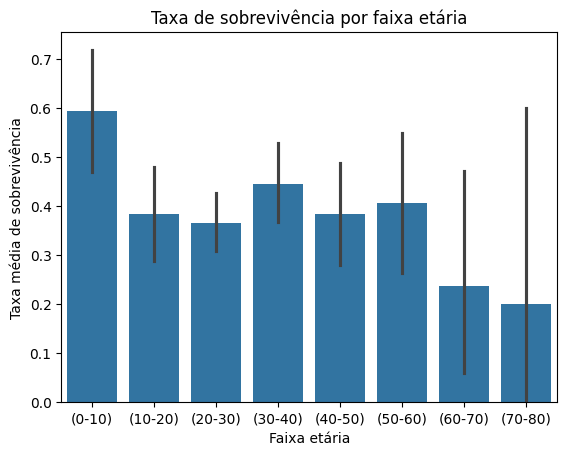

In [116]:
sns.barplot(
    data=train,
    x='AgeGroup',
    y='Survived'
)

plt.title('Taxa de sobrevivência por faixa etária')
plt.xlabel('Faixa etária')
plt.ylabel('Taxa média de sobrevivência')

plt.show()


*O gráfico mostra que a taxa de sobrevivência varia entre as faixas etárias. Algumas faixas apresentam proporções maiores de sobreviventes, enquanto outras apresentam proporções menores, sugerindo que a idade pode ter relação com a sobrevivência.Além disso, é possivel perceber que o intervalo de incerteza das faixas etárias mais elevadas são bem maiores, indicando que devem haver poucas pessoas naquela faixa, o que faz com que a taxa de sobrevivencia fique menos precisa.*


# *Outras features numéricas discretas:*

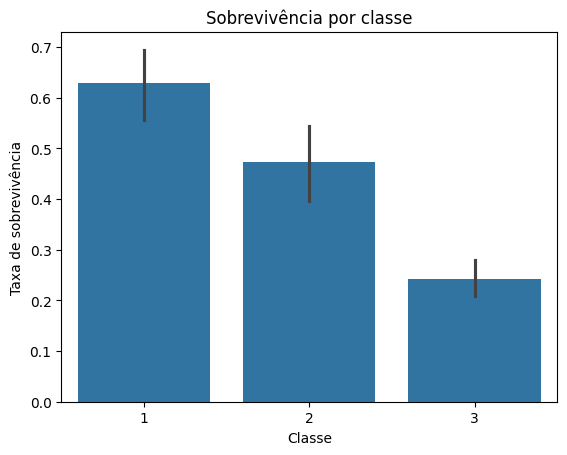

In [117]:
sns.barplot(
    data=train,
    x='Pclass',
    y='Survived'
)

plt.title('Sobrevivência por classe')
plt.xlabel('Classe')
plt.ylabel('Taxa de sobrevivência')

plt.show()

*É possivel perceber que ha uma boa diferenca entre as classes. Isso indica que essa pode ser uma feature importante e util pra esse modelo.*

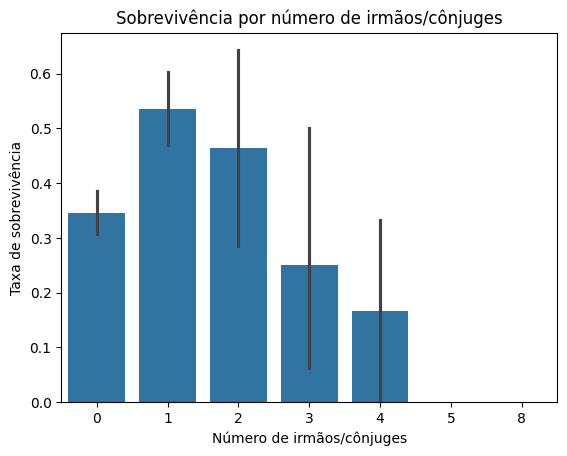

In [118]:
sns.barplot(
    data=train,
    x='SibSp',
    y='Survived'
)

plt.title('Sobrevivência por número de irmãos/cônjuges')
plt.xlabel('Número de irmãos/cônjuges')
plt.ylabel('Taxa de sobrevivência')

plt.show()


*Enquanto a queda da taxa de sobrevivencia a partir de 1 irmao/conjuge pode supor uma possivel relacao entre sobrevivencia e numero de irmaos ou conjuges, é preciso levar em conta que, visivelmente, havia menos pessoas com 2 ou mais irmaos/conjuges, o que gera esse alto intervalo de incerteza.Percebe-se que quem viajava com 1 irmao ou conjuge obteve uma taxa de sobrevivencia maior que quem viajava com nenhum.*


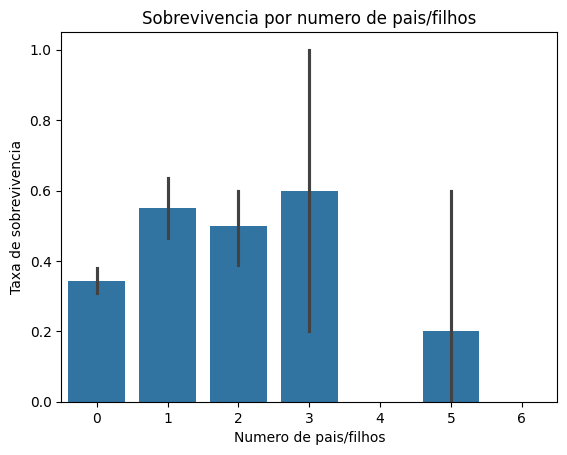

In [119]:
sns.barplot(
    data=train,
    x='Parch',
    y='Survived'
)

plt.title('Sobrevivencia por numero de pais/filhos')
plt.xlabel('Numero de pais/filhos')
plt.ylabel('Taxa de sobrevivencia')

plt.show()


*Assim como o grafico anterior, esse tambem traz um alto intervalo de incerteza, mas para valores = 3 e 5. Novamente, deve haver poucas pessoas que tinham essa quantidade de filhos ou pais.Alem disso, percebe-se que, quem estava com 1 acompanhante (seja pai ou filho), teve uma taxa de sobrevivencia consideravelmente maior que quem nao estava com nenhum.*


# *TREINAMENTO DO MODELO:*

In [120]:
X = features_num_train.drop(columns=['PassengerId', 'Survived'])

In [121]:
y = train.loc[X.index, 'Survived']

In [122]:
from sklearn.model_selection import train_test_split

In [123]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

*Acima, houve uma divisao dos dados: 80% pra treino e 20% pra validação.*

In [124]:
from sklearn.ensemble import RandomForestClassifier

In [125]:
from sklearn.metrics import accuracy_score

In [126]:
modelo = RandomForestClassifier(
    random_state=0
)

In [127]:
modelo.fit(X_train, y_train)

RandomForestClassifier(random_state=0)

In [128]:
y_pred = modelo.predict(X_val)

In [129]:
accuracy = accuracy_score(y_val, y_pred)
print(accuracy)

0.6713286713286714


*A acuracia desse modelo foi de, aproximadamente, 67%. Esse resultado é bom, visto que esse modelo não possui tratamentos avancados, mas, ao realizar a etapa de Data Cleaning, sera possivel obter uma acuracia maior.*

# *SUBMISSAO DA PREDIÇÃO:*

In [130]:
modelo_final = RandomForestClassifier(
    random_state=0
)

In [131]:
modelo_final.fit(X,y)

RandomForestClassifier(random_state=0)

In [132]:
passenger_ids = features_num_test['PassengerId']

In [133]:
X_test = features_num_test.drop(columns=['PassengerId'])

In [134]:
predicoes = modelo_final.predict(X_test)

In [135]:
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': predicoes
})

In [136]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,1
3,895,1
4,896,0


In [137]:
submission.to_csv(
    'submission.csv',
    index=False
)

# *ETAPA DE DATA CLEANING:*


In [138]:
train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeGroup'],
      dtype='object')

In [139]:
test.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [140]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    object  
 12  AgeGroup     714 non-null    category
dtypes: category(1), float64(2), int64(5), object(5)
memory usage: 84.9+ KB


In [141]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


# *Verificando quantos valores nulos têm em cada dataframe:*


In [142]:
train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
AgeGroup       177
dtype: int64

In [143]:
test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [144]:
train_clean = train.copy() # Cria uma cópia para realizar o tratamento sem alterar os dados originais

In [145]:
test_clean = test.copy() # Faz o mesmo para o conjunto de teste

# *TRATAMENTO DE VALORES AUSENTES:*

***Removendo as colunas 'cabin' e 'ticket', já que elas tem muitos valores nulos e pouca utilidade.***

In [146]:
train_clean = train_clean.drop(columns=['Cabin' ,'Ticket'])
 # Remove colunas com muitos valores ausentes para simplificar o modelo

In [147]:
train_clean.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Embarked', 'AgeGroup'],
      dtype='object')

In [148]:
test_clean = test_clean.drop(columns=['Cabin', 'Ticket'])

In [149]:
test_clean.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')

***Preenchendo os valores nulos da coluna 'Age' com a mediana dos dados, já que é uma variável contínua com muitos valores nulos:***

In [150]:
mediana_age = train_clean['Age'].median() # Calcula a mediana da idade usando os dados de treino
train_clean['Age'] = train_clean['Age'].fillna(mediana_age) # Substitui os valores ausentes do treino
test_clean['Age'] = test_clean['Age'].fillna(mediana_age) # Usa a mesma mediana no teste


***Preenchendo os valores ausentes em 'Fare' com a mediana, uma vez que é outra variável contínua:***


In [151]:
mediana_fare = train_clean['Fare'].median()
train_clean['Fare'] = train_clean['Fare'].fillna(mediana_fare)
test_clean['Fare'] = test_clean['Fare'].fillna(mediana_fare)

In [152]:
moda_embarked = train_clean['Embarked'].mode()[0]
train_clean['Embarked'] = train_clean['Embarked'].fillna(moda_embarked)
test_clean['Embarked'] = test_clean['Embarked'].fillna(moda_embarked)

***Criação de grupos a partir de variaveis contínuas:***


In [153]:
train_clean['AgeGroup'] = pd.cut(train_clean['Age'], bins = 5) # Divide a idade em 5 faixas para criar uma variável categórica
test_clean['AgeGroup'] = pd.cut(test_clean['Age'], bins = 5)

In [154]:
train_clean['FareGroup'] = pd.qcut(train_clean['Fare'], q = 6) # Divide as tarifas em 6 grupos com quantidades semelhantes de observações
test_clean['FareGroup'] = pd.qcut(test_clean['Fare'], q = 6)

In [155]:
train_clean

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,AgeGroup,FareGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S,"(16.336, 32.252]","(-0.001, 7.775]"
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C,"(32.252, 48.168]","(52.369, 512.329]"
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S,"(16.336, 32.252]","(7.775, 8.662]"
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S,"(32.252, 48.168]","(52.369, 512.329]"
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S,"(32.252, 48.168]","(7.775, 8.662]"
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,13.0000,S,"(16.336, 32.252]","(8.662, 14.454]"
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,30.0000,S,"(16.336, 32.252]","(26.0, 52.369]"
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,23.4500,S,"(16.336, 32.252]","(14.454, 26.0]"
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,30.0000,C,"(16.336, 32.252]","(26.0, 52.369]"


# *RESPONDENDO PERGUNTAS:*

1. Por que voce optou por remover as colunas “Cabin” e “Ticket”? Ha algum
cenario em que essas colunas poderiam ser uteis?

R) *Eu optei por remover essas duas colunas devido a quantidade de valores nulos presentes, além do fato de que a coluna Ticket possuia inumeros codigos distintos com vários numeros, o que poluia o dataser. A cabine poderia ser útil para analisarmos a proximidade da cabine aos botes de salva-vidas, por exemplo. Já o ticket, poderia indicar familiarem que estavam viajando juntos, mas que nao possuiam sobrenome igual.*



2. Voce escolheu preencher os valores ausentes de “Age” e “Fare” com a mediana.
Em quais situacoes a media ou moda seriam mais apropriadas? Justifique.

R) *A média seria mais apropriada para casos em que nao tivessem o risco da presença de outliers, uma vez que a média é extremamente sensível a esses valores extremos (enquanto a mediana nao é). Já a moda seria mais apropriada para casos em que houvessem variaveis categóricas ou muitos valores repetitivos, uma vez que ela iria usar o valor que mais se repete para se basear pros valores ausentes.*

3. A substituicao dos NaNs da coluna “Embarked” foi feita com a moda. Quais os
riscos de aplicar esse tipo de preenchimento em variaveis categoricas?


R) *Esse tipo de preenchimento pode gerar riscos, como o aumento do vies, ja que preencher colunas nulas com o valor da maioria pode atribuir caracteristicas erradas ao passageiro e viciar o modelo, e também pode gerar uma distorção da distribuição, visto que você está aumentando artificialmente a proporcao da categoria mais comum.*


4. Voce criou faixas para as variaveis contınuas “Age” e “Fare”. Quais sao as
vantagens de agrupar variaveis contınuas? Ha desvantagens?

R) *A vantagem de agrupar variaveis continuas, se da pelo fato de que, por serem variaveis que possuem valores muito distintos, há uma diferença muito grande nessas colunas entre os passageiros, o que dificulta fazer uma analise com essas variaveis. Com isso, ao agrupar essas variaveis, permitimos que haja menos distincao entre os passageiros, facilitando, assim, o uso dessas variaveis para uma analise. Como desvantagem, o agrupamento de ambas pode impedir uma análise mais refinada e específica para determinada Age ou Fare, ou seja, acaba gerando uma perda de informação.*


5. Durante a limpeza, quais decisoes voce acredita que mais impactaram positivamente a preparacao do banco de dados para modelagem? Justifique.

R) *Sem dúvidas, o preenchimento das variáveis nulas com a mediana e a moda, uma vez que evitou a perda de informações, e a exclusão das colunas que apresentavam valores nulos e que não impactariam na modelagem.*

6. Se o dataset fosse muito maior e mais complexo, como voce adaptaria seu processo
de data cleaning para lidar com multiplas fontes de dados e diferentes tipos de ruıdos?

R) *Eu provavelmente iria tentar preencher os dados nulos, sempre que desse, com a mediana ou a moda (evitaria a média, ja que um dataset maior pode possuir outliers), eliminaria colunas que não fossem agregar na análise e criaria os agrupamentos para facilitar a visualizacao das tabelas.*

_____________________________________________
# *Aperfeiçoamento da modelagem:*
_____________________________________________

In [156]:
train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Fare         891 non-null    float64 
 9   Embarked     891 non-null    object  
 10  AgeGroup     891 non-null    category
 11  FareGroup    891 non-null    category
dtypes: category(2), float64(2), int64(5), object(3)
memory usage: 72.0+ KB


# *Separando as variaveis numericas e categoricas:*

In [157]:
cat_cols = train_clean.select_dtypes(include=['object']).columns
num_cols = train_clean.select_dtypes(include=['float64', 'int64']).columns

In [158]:
print('Colunas categoricas:', cat_cols)
print('Colunas numericas:', num_cols)

Colunas categoricas: Index(['Name', 'Sex', 'Embarked'], dtype='object')
Colunas numericas: Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


# *Importando o OneHotEncoder*

In [159]:
from sklearn.preprocessing import OneHotEncoder # Transforma categorias em colunas numéricas para evitar uma ordem artificial entre as categorias.

# *Criando o encoder:*

In [160]:
encoder = OneHotEncoder(
    handle_unknown='ignore',\
    sparse_output=False
)

In [161]:
from sklearn.preprocessing import OneHotEncoder

def one_hot_encode(data, columns):
    
    data = data.copy()
    
    encoder = OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ) # criando o OneHot
    
    for column in columns: #passa por cada coluna aplicando o OneHot
        
        encoded = encoder.fit_transform(data[[column]])
        
        feature_names = encoder.get_feature_names_out([column])
        
        encoded_df = pd.DataFrame(
            encoded,
            columns=feature_names,
            index=data.index
        )
        
        data = data.drop(columns=[column])
        
        data = pd.concat(
            [data, encoded_df],
            axis=1
        )
    
    return data

# *Aplicando o OneHot:*

In [162]:
categorical_to_encode = [
    'Sex', # Categoria sem ordem natural
    'Embarked', # Categoria sem ordem natural, ponto de embarque do passageiro
    'AgeGroup', # Faixas etárias tratadas como categorias
    'FareGroup' # Faixas de tarifa tratadas como categorias
]

In [163]:
train_encoded = one_hot_encode(
    train_clean,
    categorical_to_encode
) # Transforma as variáveis categóricas em colunas numéricas usando One-Hot Encoding

In [164]:
test_encoded = one_hot_encode(
    test_clean,
    categorical_to_encode
)

In [165]:
train_encoded.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Fare,Sex_female,Sex_male,...,"AgeGroup_(16.336, 32.252]","AgeGroup_(32.252, 48.168]","AgeGroup_(48.168, 64.084]","AgeGroup_(64.084, 80.0]","FareGroup_(-0.001, 7.775]","FareGroup_(7.775, 8.662]","FareGroup_(8.662, 14.454]","FareGroup_(14.454, 26.0]","FareGroup_(26.0, 52.369]","FareGroup_(52.369, 512.329]"
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,7.2500,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,71.2833,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,7.9250,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,53.1000,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,8.0500,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [166]:
train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   PassengerId                  891 non-null    int64  
 1   Survived                     891 non-null    int64  
 2   Pclass                       891 non-null    int64  
 3   Name                         891 non-null    object 
 4   Age                          891 non-null    float64
 5   SibSp                        891 non-null    int64  
 6   Parch                        891 non-null    int64  
 7   Fare                         891 non-null    float64
 8   Sex_female                   891 non-null    float64
 9   Sex_male                     891 non-null    float64
 10  Embarked_C                   891 non-null    float64
 11  Embarked_Q                   891 non-null    float64
 12  Embarked_S                   891 non-null    float64
 13  AgeGroup_(0.34, 16.3

In [167]:
from sklearn.preprocessing import OrdinalEncoder

In [168]:
ordinal_encoder = OrdinalEncoder() # usado quando há uma ordem


# *Preparando o modelo:*

In [169]:
X = train_encoded.drop(columns=['Survived', 'Name']) # Define as features usadas pelo modelo e remove a variável de interesse e o nome.
y = train_encoded['Survived'] # Define a variável que quero: sobrevivencia

# *Separando treino e validação:*

In [170]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20, # Reserva 20% dos dados pra validação
    random_state=0 # Mantém a divisão reproduzível
)

# *Criando o Random Forest:*

In [171]:
model = RandomForestClassifier(
    random_state=0
)

# *Conferindo se nao há mais 'object'*:

In [172]:
X_train.dtypes

PassengerId                      int64
Pclass                           int64
Age                            float64
SibSp                            int64
Parch                            int64
Fare                           float64
Sex_female                     float64
Sex_male                       float64
Embarked_C                     float64
Embarked_Q                     float64
Embarked_S                     float64
AgeGroup_(0.34, 16.336]        float64
AgeGroup_(16.336, 32.252]      float64
AgeGroup_(32.252, 48.168]      float64
AgeGroup_(48.168, 64.084]      float64
AgeGroup_(64.084, 80.0]        float64
FareGroup_(-0.001, 7.775]      float64
FareGroup_(7.775, 8.662]       float64
FareGroup_(8.662, 14.454]      float64
FareGroup_(14.454, 26.0]       float64
FareGroup_(26.0, 52.369]       float64
FareGroup_(52.369, 512.329]    float64
dtype: object

# *Treinando:*

In [173]:
model.fit(X_train, y_train) # Treina o Random Forest usando as features e os resultados conhecidos. 

RandomForestClassifier(random_state=0)

# *Fazendo previsões:*

In [174]:
predictions = model.predict(X_valid) # Usa o modelo treinado para prever a sobrevivência dos passageiros da validação

# *Calculando a acurácia:*

In [175]:
accuracy = accuracy_score(y_valid, predictions) # Compara as previsões com os resultados reais e calcula a acurácia

print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 83.24%


*Ao aplicar encoding às variáveis categóricas, o modelo passa a utilizar informações que anteriormente não estavam representadas numericamente. Observa-se, então, que a acurácia obtida nesse novo modelo foi consideravelmente maior que a anterior, mostrando que esse modelo é mais preciso que o outro. Diante a esse aumento, podemos conlcuir que a inclusão de variáveis categóricas, especialmente Sex e Embarked,contribuíram consideravelmente para o aumento da acurácia do modelo.*

# *Pipelines*

A pipeline organiza as etapas de pré-processamento e treinamento em uma única sequência, garantido que elas sejam executadas de forma consistente.

In [176]:
train_pipeline = train.copy()

In [177]:
from sklearn.compose import ColumnTransformer # Define o que será feito para as colunas
from sklearn.pipeline import Pipeline 
from sklearn.impute import SimpleImputer # é o que preenche valores ausentes
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split # separa os dados em conjuntos de treinamento e validação
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [178]:
numerical_imputer = 'median'
categorical_imputer = 'most_frequent'

In [179]:
def evaluate_pipeline(
    data,
    encoder,
    model,
    numerical_imputer,
    categorical_imputer
):
    
    data = data.copy()
    
    X = data.drop(columns=['Survived'])
    y = data['Survived']
    
    X_train, X_valid, y_train, y_valid = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=0
    )
    
    numerical_features = X.select_dtypes(
        include=['int64', 'float64']
    ).columns
    
    categorical_features = X.select_dtypes(
        include=['object']
    ).columns
    
    numerical_pipeline = Pipeline([
        ('imputer', SimpleImputer(
            strategy=numerical_imputer
        ))
    ]) # Pipeline para tratar valores ausentes das variáveis numéricas
    
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(
            strategy=categorical_imputer
        )),
        ('encoder', encoder)
    ]) # Para categorias: primeiro preenche valores ausentes e depois aplica o encoding
    
    preprocessor = ColumnTransformer([
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ]) # Aplica tratamentos diferentes às variáveis numéricas e categóricas
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ]) # Junta todo o pré-processamento e o modelo em uma única sequência
    
    pipeline.fit(X_train, y_train)
    
    predictions = pipeline.predict(X_valid)
    
    accuracy = accuracy_score(
        y_valid,
        predictions
    )
    
    return accuracy * 100

In [180]:
imputation_strategies = [
    'mean',
    'most_frequent',
    'median',
    'constant'
]

# *Criando os encoders:*

In [181]:
encoders = {
    'one-hot': OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ),
    'ordinal': OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value= -1
    )
}

In [182]:
results = []

for encoder_name, encoder in encoders.items(): # testa cada estratégia de encoding
    
    for imputer_strategy in imputation_strategies: # testa diferentes estratégias de imputação
        
        if imputer_strategy == 'constant':
            numerical_strategy = 'constant'
        else:
            numerical_strategy = imputer_strategy
        
        model = RandomForestClassifier(
            random_state=0
        )
        
        accuracy = evaluate_pipeline(
            train_pipeline,
            encoder,
            model,
            numerical_strategy,
            'most_frequent'
        )
        
        results.append({
            'Encoder': encoder_name,
            'Imputer': imputer_strategy,
            'Accuracy': accuracy
        }) # Armazena a combinação utilizada e sua respectiva acurácia

# *Vendo a acurácia de cada estratégia:*

In [183]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    'Accuracy',
    ascending=False
)

,Encoder,Imputer,Accuracy
3,one-hot,constant,86.033520
1,one-hot,most_frequent,84.916201
0,one-hot,mean,84.357542
2,one-hot,median,84.357542
5,ordinal,most_frequent,82.681564
6,ordinal,median,79.888268
7,ordinal,constant,79.329609
4,ordinal,mean,78.770950


In [184]:
best_result = results_df.sort_values(
    'Accuracy',
    ascending=False
).iloc[0]

print(best_result)

Encoder      one-hot
Imputer     constant
Accuracy    86.03352
Name: 3, dtype: object


As combinações testadas apresentaram desempenho superior ao modelo inicial em diferentes configurações. A tabela permite identificar qual combinação de encoding e imputação apresentou a maior acurácia.

In [197]:
numerical_features = X.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant'))
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=0))
])

# *Cross Validation*

*Em cada divisão, 80% dos dados são usados para treinamento e os outros 20% para validação, alternando quais observações ficam em cada conjunto.*

# *Importando a biblioteca:*

In [186]:
from sklearn.model_selection import cross_val_score
#importando o cross validation

# *Avaliando a melhor Pipeline*

Vendo qual foi a melhor combinação de pré-processamentos

In [198]:
scores = cross_val_score(
    pipeline, # random forest
    X,
    y,
    cv=5, # Divide os dados em 5 partes para realizar a validação cruzada
    scoring='accuracy' # usa a acurácia como métrica de avaliação
)

In [200]:
print('Scores:', scores)
print('Acuracia média:', scores.mean()* 100)

Scores: [0.74301676 0.79213483 0.84831461 0.80898876 0.83146067]
Acuracia média: 80.47831272362063


*O modelo apresentou accuracy média de 80,5% aproximadamente nas cinco divisões. Isso fornece uma avaliação mais robusta do desempenho do modelo do que uma única divisão treino/validação.*

# *Gradient Boosting Classifier*

In [189]:
from sklearn.ensemble import GradientBoostingClassifier

In [190]:
gb_model = GradientBoostingClassifier(
    random_state=0, # torna os resultados reprodutíveis quando há componentes aleatórios
    n_iter_no_change=100 # se o desempenho deixar de melhorar durante determinado número de iteracoes, o treinamento pode parar.
)

# *Definindo X e y*

In [191]:
X = train_encoded.drop(columns=['Survived', 'Name'])
y = train_encoded['Survived']

# *Fazer Cross Validation com Gradient Boosting*

In [192]:
gb_pipeline = Pipeline([
    ('preprocessor', preprocessor), # Aplica o mesmo pré-processamento aos dados
    ('model', gb_model) # Usa Gradient Boosting como modelo
])

In [193]:
gb_scores = cross_val_score(
    gb_pipeline,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Scores:", gb_scores)
print(
    f"Accuracy média: "
    f"{gb_scores.mean() * 100:.2f}%"
)

Scores: [0.62011173 0.8258427  0.8258427  0.83707865 0.84269663]
Accuracy média: 79.03%


In [194]:
rf_accuracy = scores.mean() # Calcula a acurácia média do Random Forest nas 5 divisões
gb_accuracy = gb_scores.mean() # Calcula a acurácia média do Gradient Boosting nas 5 divisões

# *Comparando os modelos:*

In [195]:
print(f'Random Forest: {rf_accuracy * 100:.2f}%')
print(f'Gradient Boosting: {gb_accuracy * 100:.2f}%')

Random Forest: 80.48%
Gradient Boosting: 79.03%


In [196]:
if gb_accuracy > rf_accuracy:
    print("Gradient Boosting apresentou melhor desempenho.")
elif rf_accuracy > gb_accuracy:
    print("Random Forest apresentou melhor desempenho.")
else:
    print("Os dois modelos apresentaram o mesmo desempenho.")

Random Forest apresentou melhor desempenho.
